In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import datasets, transforms
import numpy as np
import copy
import math
from scipy.stats import norm
from opacus import PrivacyEngine

### Utility functions

Useful functions...

In [2]:
def moving_avg(x, window=10):
    x = np.array(x)
    return np.convolve(x, np.ones(window)/window, mode="valid")

def show_reconstructions(rec_x_per_epoch,
                         epochs,
                         batch_size,
                         save_path,
                         cmap="gray"):
    """
    rec_x_per_epoch:
        list of length num_epochs
        each element is a list of length batch_size
        each entry is a flattened (1024,) image

    Output layout:
        rows    = batch elements
        columns = epochs
    """

    num_epochs = epochs
    batch_size = batch_size

    fig, axes = plt.subplots(
        batch_size,
        num_epochs,
        figsize=(num_epochs * 1.5, batch_size * 1.5),
        squeeze=False
    )

    for e in range(num_epochs):
        for b in range(batch_size):

            x_rec = rec_x_per_epoch[e][b]

            # handle torch tensors
            if hasattr(x_rec, "detach"):
                x_rec = x_rec.detach().cpu().numpy()

            x_rec = np.squeeze(x_rec)
            img = x_rec.reshape(28, 28)

            ax = axes[b, e]
            ax.imshow(img, cmap=cmap)

            ax.set_xticks([])
            ax.set_yticks([])

            # thin red border
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(0.5)

            # epoch label on top row
            if b == 0:
                ax.set_title(f"Ep. {e+1}", fontsize=28, pad=2)

    # remove all spacing
    plt.subplots_adjust(
        left=0,
        right=1,
        top=1,
        bottom=0,
        wspace=0.03,
        hspace=0
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

def total_variation_loss(x, height=28, width=28):
    """
    Batched Total Variation Loss.

    Args:
        x: torch.Tensor of shape
            (B, H*W)      or
            (B, 1, H, W)

    Returns:
        scalar tensor = mean TV across batch
    """

    # if flattened → reshape
    if x.dim() == 2:
        B = x.size(0)
        img = x.view(B, 1, height, width)

    # already image-shaped
    elif x.dim() == 4:
        img = x

    else:
        raise ValueError("x must be (B,H*W) or (B,1,H,W)")

    # horizontal & vertical diffs
    diff_h = img[:, :, :, 1:] - img[:, :, :, :-1]
    diff_v = img[:, :, 1:, :] - img[:, :, :-1, :]

    # TV per image
    tv_per_img = (
        diff_h.pow(2).sum(dim=(1,2,3)) +
        diff_v.pow(2).sum(dim=(1,2,3))
    )

    # mean over batch
    return tv_per_img.mean()



Next, we define our simple MLP model. It consists of
* one hidden dimension of size 256 and
* ReLU activations.

In [43]:
def grad_norm(model, norm_type=2):
    """
    Computes the norm of gradients of all parameters in a model.

    Args:
        model (nn.Module): PyTorch model with computed gradients
        norm_type (float): type of norm (2 for L2, 1 for L1, float('inf') for max)

    Returns:
        float: gradient norm
    """
    total_norm = 0.0
    num_elems = 0

    if norm_type == float('inf'):
        total_norm = max(
            p.grad.abs().max().item()
            for p in model.parameters()
            if p.grad is not None
        )
        return total_norm

    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(norm_type)
            total_norm += param_norm.item() ** norm_type
            num_elems += p.grad.numel()

    total_norm = total_norm ** (1.0 / norm_type)
    return total_norm, num_elems


class MLP(nn.Module):
    '''
    Multi-Layer perceptron
    '''
    def __init__(self, input_dim, output_dim, hidden_dim=256):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            #nn.Linear(hidden_dim, hidden_dim),
            #nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return (self.layers(x))

Next we preprocess our dataset. The dataset we use is a random subset of size $n$ of the [MNIST](http://yann.lecun.com/exdb/mnist/) dataset. 

In [4]:
def prepare_mnist(n):
    '''
    Loads and prepares the MNIST dataset. Takes as input the number of training points n and return X, y, means. 
    '''

    # Define transform: convert to tensor [0,1] and flatten to 784-dim vector
    transform = transforms.Compose([
        transforms.ToTensor(),                      # -> (1, 28, 28), values in [0,1]
        transforms.Lambda(lambda x: x.view(-1))     # -> (784,)
    ])

    # Load the training dataset
    train_dataset = datasets.MNIST(root='../data/mnist', train=True, download=True, transform=transform)

    # Load the test dataset
    test_dataset = datasets.MNIST(root='../data/mnist', train=False, download=True, transform=transform)
    # Pick a smaller subset of training data (e.g. 5000 samples)
    subset_size = n
    indices = torch.randperm(len(train_dataset))[:subset_size]  # random subset
    train_dataset = Subset(train_dataset, indices)

    # Convert subset to arrays X, y
    X = []
    y = []
    for i in range(len(train_dataset)):
        data, label = train_dataset[i]
        X.append(data.numpy())   # convert tensor -> numpy
        y.append(label)

    X = np.stack(X)   # shape (n, 784)

    y = np.array(y)   # shape (n,)

    means = []
    M=10
    for c in range(M):
        class_samples = X[y == c]
        class_mean = np.mean(class_samples, axis=0)
        means.append(class_mean)

    means = np.array(means)   # shape (10, 784)

    return X, y, means 

def prepare_data_loader(X, y, batch_size=1):
    '''
    Prepares the data loader and returns it.
    Input: - X: the data.
           - y: the labels of the data.
           - batch_size. Default is 1.
    Returns: a DataLoader object ready for training and one for testing and the total number of training data.
    '''
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.long))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                 torch.tensor(y_test, dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    total_samples = len(train_loader) * train_loader.batch_size

    return train_loader, test_loader, total_samples


X, y, means = prepare_mnist(5000)
train_loader , test_loader, total_samples = prepare_data_loader(X, y)
print(X.shape)

(5000, 784)


## Train the model 


In [5]:
def train(epochs, optimizer, loss_function):
    loss_per_epoch = []
    test_acc_per_epoch = []
    train_acc_per_epoch = []
    for epoch in range(epochs):
        model.train()
        tot_loss = 0
        correct, total = 0, 0
        for i, data in enumerate(train_loader, 0):
            x_batch, y_batch = data
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_function(outputs, y_batch)
            loss.backward()
            optimizer.step()
            tot_loss += loss.item()

            outputs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        loss_per_epoch.append(tot_loss)
        train_acc_per_epoch.append(correct/total)
    
        # Evaluate after each epoch
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                outputs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
            acc = correct / total
            test_acc_per_epoch.append(acc)
    
        print(f"Epoch {epoch+1}: Test acc: {test_acc_per_epoch[epoch]:.4f}, train acc: {train_acc_per_epoch[epoch]:.4f}, epoch loss: {loss_per_epoch[epoch]:.4f}")
    
    return test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, tot_loss


In [ ]:
model = MLP(X.shape[1], 10)
loss_function = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epochs = 15

test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, cummulative_loss = train(epochs, optimizer, loss_function)

In [ ]:
plt.figure(figsize=(25, 10))
plt.rcParams.update({'font.size': 28})
plt.subplot(1,2,1)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(range(1, epochs+1), test_acc_per_epoch , linestyle='-', linewidth=3, label='noisless')

plt.subplot(1,2,2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(range(1, epochs+1), loss_per_epoch , linestyle='-', linewidth=3, label='noisless')

plt.show()


## Make the Gradient Decent updates Differantially Private.

Make the Gradient Decent updates Differantially Private by adding callibrated noise based on the **gaussian mechanism** in order to gurantee $(\epsilon, \delta)$-DP.

In [49]:
def cross_entropy_for_onehot(pred, target):
    return torch.mean(torch.sum(- target * F.log_softmax(pred, dim=-1), 1))

def add_noise_to_grads(model, epsilon, sensetivity, q, delta=1e-5):
    '''
    Add noise to the gradients of the model via the subsampled one shot gaussian mechanism.
    '''
    # Compute gradient norm and size
    grad_sq_sum = 0.0
    num_elems = 0
    grad_tuple = []

    for p in model.parameters():
        if p.grad is not None:
    
            if not torch.isfinite(p.grad).all():
                p.grad.data = torch.nan_to_num(
                    p.grad.data,
                    nan=0.0,
                    posinf=1e4,
                    neginf=-1e4
                )
    
    if epsilon != None:
        delta_2 = 2*sensetivity
        alpha_star = find_alpha_star(epsilon, delta, q)
        sigma = delta_2/(math.sqrt(2*alpha_star))
        if math.isnan(sigma):
            sigma = 1e12
    else:
        sigma = 1e12 # infinity (Very very large)

    # Add Gaussian noise to each gradient
    for p in model.parameters():
        if p.grad is not None:
            noise = torch.randn_like(p.grad) * sigma
            if epsilon != None:
                p.grad.add_(noise)
            
            grad_tuple.append(p.grad)
            
    grad = tuple(g.detach().clone() for g in grad_tuple)
    #grad_tuple = tuple(grad_tuple)
    return sigma, grad_tuple

    
def dlg_attack(original_dy_dx, model, criterion=cross_entropy_for_onehot, loss_function="grad_diff", batch_size=1):
    '''
    iDLG attack.
    original_dy_dx: the gradient of the model's training shared to the clients.
    model: the model to be attacked
    criterion: the loss funtion used by the model
    loss_funtion: the loss funtion used by th attack. 'grad_diif' is the original, 'cosine similarity' for the cosine similarity loss funtion.
    '''
    # generate dummy data and label
    dummy_data = torch.randn((batch_size,784)).requires_grad_(True)
    dummy_label = torch.randn((batch_size,10), requires_grad=True)
    optimizer = torch.optim.Adam([dummy_data, dummy_label], lr=0.1)
    #optimizer = torch.optim.LBFGS([dummy_data,], lr=1)
    #criterion_iDLG = nn.CrossEntropyLoss()

    history = []
    convergance = 1e10
    prev_loss = 1e10
    current_loss = 1e10
    iters = 0
    while (iters < 3000 and current_loss>1e-3):
        if iters != 0:
            prev_loss = current_loss
        def closure():
            optimizer.zero_grad()
    
            pred = model(dummy_data)
            dummy_onehot_label = F.softmax(dummy_label, dim=-1)
            #last_bias_grad = original_dy_dx[-1]   
            #label_pred = torch.argmin(last_bias_grad).view(1)
            #dummy_loss = criterion_iDLG(pred, label_pred)
            dummy_loss = criterion(pred, dummy_onehot_label) 
            dummy_dy_dx = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)

            grad_diff = 0
            grad_count = 0
            if loss_function=='cosine similarity':
                lambda_tv = 1e-6
                grad_diff = 0
                total = 0
                
                for gx, gy in zip(dummy_dy_dx, original_dy_dx):
                    cos = F.cosine_similarity(gx.reshape(1, -1), gy.reshape(1, -1), eps=1e-8)
                    
                    n = gy.numel()
                    grad_diff += n * (1 - cos)
                    total += n
                
                grad_diff = grad_diff / total
                tv_loss = total_variation_loss(dummy_data,  height=28, width=28)
                grad_diff = grad_diff + lambda_tv * tv_loss

            elif loss_function == 'nDLG':
                for gx, gy in zip(dummy_dy_dx, original_dy_dx): 
                    gx_norm = torch.norm(gx, p=2)
                    gy_norm = torch.norm(gy, p=2)
    
                    gx_normalized = gx / (gx_norm + 1e-12)
                    gy_normalized = gy / (gy_norm + 1e-12)
    
                    grad_diff += ((gx_normalized - gy_normalized) ** 2).sum()
                    #grad_diff += ((gx - gy) ** 2).sum()
            else:
                for gx, gy in zip(dummy_dy_dx, original_dy_dx): 
                    grad_diff += ((gx - gy) ** 2).sum()

            grad_diff.backward()
    
            return grad_diff
    
        current_loss = optimizer.step(closure)
        dummy_data.data.clamp_(0,1)
        dummy_label.data.clamp_(-10,10)
        current_loss = current_loss.item()
        convergance = np.abs(current_loss - prev_loss)/np.abs(current_loss)
        history.append(dummy_data.cpu())
        iters += 1
       
    print(f'Iters: {iters}, Loss: {current_loss:.4f}, Convergance value: {convergance:.6f}')
    return history

def noisy_train(model, train_loader, test_loader, epochs, optimizer, loss_function,
                 epsilon, attack='grad_diff', batch_size=1, max_grad_norm=1):
    loss_per_epoch = []
    test_acc_per_epoch = []
    train_acc_per_epoch = []
    rec_x_per_epoch = []
    rec_error_per_epoch = []
    grad_norm_per_epoch = []
    avg_snr_per_epoch = []
    
    
    for epoch in range(epochs):
        model.train()
        tot_loss = 0
        correct, total = 0, 0
        rec_error, sigma, emp_snr_avg = 0.0, 0.0, 0.0

        rec_error_per_epoch.append([])
        grad_norm_per_epoch.append([])
        for i, data in enumerate(train_loader, 0):
            x_batch, y_batch = data
            optimizer.zero_grad()

            outputs = model(x_batch)
            loss = loss_function(outputs, y_batch)
            loss.backward()
            norm_before = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
            norm_after, N = grad_norm(model)
            sigma, grad = add_noise_to_grads(model, epsilon, max_grad_norm, B/len(train_loader)) # Here we calculate std based on snr and add noise to gradients.
            snr1 = norm_after**2/(N*sigma**2)
            snr2 = find_alpha_star(epsilon, 1e-5, batch_size/5000)/N
            emp_snr_avg += snr1
            #print(f'N: {N}, simga: {sigma:.5f}, signal norm: {norm_after}, \nSNR empirical: {snr1}\nSNR theoretical: {snr2}')
            
            # Perform attack. 
            if (i < 0): 
                # Share the gradients with clients.
                # Make a deep copy of the model so we avoid conflicts with backpropagation.
                frozen_model = copy.deepcopy(model).eval()

                # Try the attack many times to avoid bad reconstructions due to bad initialization of data.
                for trial in range(1):    
                    rec_x = []
                    history = dlg_attack(grad, frozen_model, loss_function=attack, batch_size=batch_size)

                    rec_x_batched = history[-1].detach()
                    rec_error = 0.0
                    for b in range(batch_size):
                        rec_x.append(rec_x_batched[b].flatten())
                        x = x_batch[b].detach().flatten()
                        rec_error += F.cosine_similarity(rec_x[b], x, dim=0)
                    rec_error = rec_error.item()/batch_size # Take the average loss of all batch
                    if rec_error > 0.6:
                        break 
                
                if i == 0:
                    rec_x_per_epoch.append(rec_x)
                rec_error_per_epoch[epoch].append(rec_error)
                grad_norm_per_epoch[epoch].append(grad_norm(model))
                print(f'Iter: {i+1}, rec_error: ', rec_error, f',grad L2 norm: {grad_norm_per_epoch[epoch][-1]}, Sigma: {sigma}')
            
            optimizer.step()
    

            tot_loss += loss.item()

            outputs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        

        loss_per_epoch.append(tot_loss)
        train_acc_per_epoch.append(correct / total)
        avg_snr_per_epoch.append(emp_snr_avg * (B/len(train_loader)))

        # Evaluation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                outputs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

        acc = correct / total
        test_acc_per_epoch.append(acc)
        
        print(f"Epoch {epoch+1}: Test acc: {acc:.4f}, train acc: {train_acc_per_epoch[epoch]:.4f}, epoch loss: {loss_per_epoch[epoch]:.4f}, reconstruction error: {rec_error:.4f}, sigma: {sigma:.4f}, grad_norm berfor:{norm_before:.4f} grad_norm: {norm_after:.4f}")
        print(f"Empirical SNR: {avg_snr_per_epoch[-1]}, alpha: {snr2}")
    #show_reconstructions(rec_x_per_epoch, epochs, batch_size, f"./grid_{attack}_eps{epsilon}.png")
    error_grads = (rec_error_per_epoch, grad_norm_per_epoch)
    return test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, tot_loss, rec_x_per_epoch, error_grads, avg_snr_per_epoch

In [ ]:
B=1
X, y, means = prepare_mnist(5000)
train_loader , test_loader, total_samples = prepare_data_loader(X, y, batch_size=B)

epochs = 20
epsilon = 10
max_grad_norm = 1

model = MLP(X.shape[1], 10, hidden_dim=512)
loss_function = nn.CrossEntropyLoss(reduction="mean")
#optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
noisy_test_acc_per_epoch, noisy_train_acc_per_epoch, noisy_loss_per_epoch, noisy_cummulative_loss, noisy_rec_x_per_epoch, error_grads, avg_snr_per_epoch = noisy_train(model, train_loader, test_loader, 
                                                                                                                                           epochs, optimizer, loss_function, epsilon, attack='cosine similarity', batch_size=B,
                                                                                                                                                   max_grad_norm=max_grad_norm)
errors = np.array(error_grads[0])
grads = np.array(error_grads[1])

Epoch 1: Test acc: 0.4480, train acc: 0.2672, epoch loss: 8467.3578, reconstruction error: 0.0000, sigma: 0.4275, grad_norm berfor:19.2302 grad_norm: 1.0000
Empirical SNR: 8.172309743672613e-06, alpha: 1.7151981868862574e-05


<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_106986/3401825075.py:27: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel(r'cos($\hat{x}$, x)')


"\nplt.plot(range(len(avg_snr_per_epoch)), avg_snr_per_epoch, linewidth=3)\nplt.xticks(range(len(avg_snr_per_epoch)))\nplt.xlabel('Epoch')\nplt.ylabel(r'Empirical SNR')\nplt.title('Empirical SNR per epoch')\nplt.grid(True, alpha=0.7)\nplt.savefig('./subOSGM_emp_snr_per_epoch_eps10_delta1e-5_1NN.png')\n"

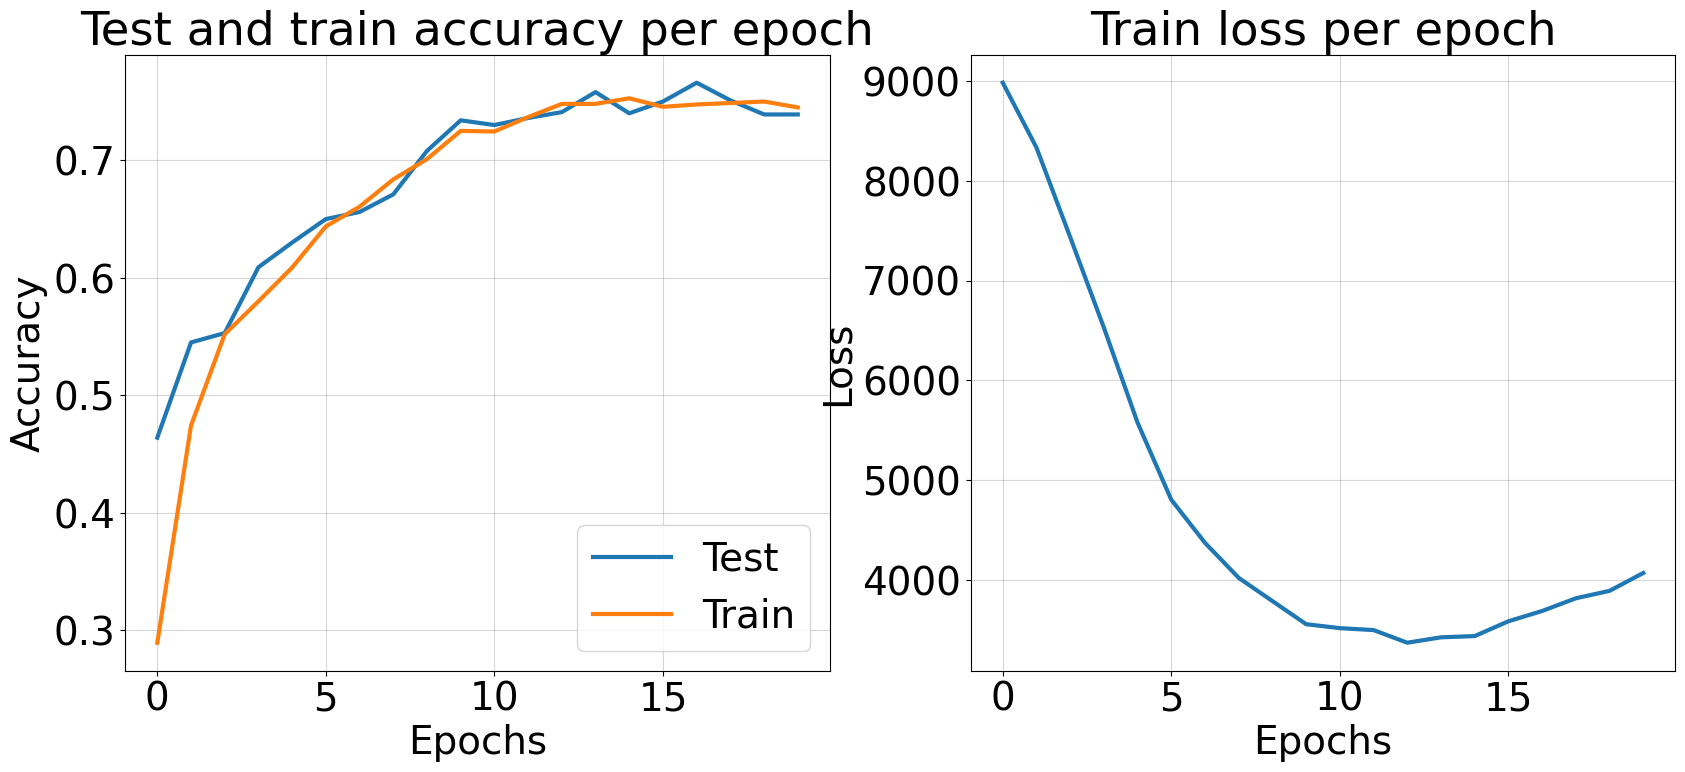

In [47]:
plt.figure(figsize=(20, 8))
plt.rcParams.update({'font.size': 28})


plt.subplot(1,2,1)
plt.plot(noisy_test_acc_per_epoch, linewidth=3, label='Test')
plt.plot(noisy_train_acc_per_epoch, linewidth=3, label='Train')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Test and train accuracy per epoch")
plt.grid(True, alpha=0.5)
plt.legend()


plt.subplot(1,2,2)
plt.plot(noisy_loss_per_epoch, linewidth=3)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train loss per epoch")
plt.grid(True, alpha=0.5)

plt.savefig('./subOSGM_acc_loss_eps10_delta1e-5_1NN.png')

'''
plt.plot(errors, linewidth=3)
plt.xlabel('Epoch')
plt.ylabel(r'cos($\hat{x}$, x)')
plt.xticks(range(len(avg_snr_per_epoch)))
plt.title('Reconstruction Quality per Epoch')
plt.grid(True, alpha=0.7)
plt.savefig('./subOSGM_rec_error_eps10_delta1e-5_1NN.png')
'''
'''
plt.plot(range(len(avg_snr_per_epoch)), avg_snr_per_epoch, linewidth=3)
plt.xticks(range(len(avg_snr_per_epoch)))
plt.xlabel('Epoch')
plt.ylabel(r'Empirical SNR')
plt.title('Empirical SNR per epoch')
plt.grid(True, alpha=0.7)
plt.savefig('./subOSGM_emp_snr_per_epoch_eps10_delta1e-5_1NN.png')
'''

### One shot gaussian mechanism.

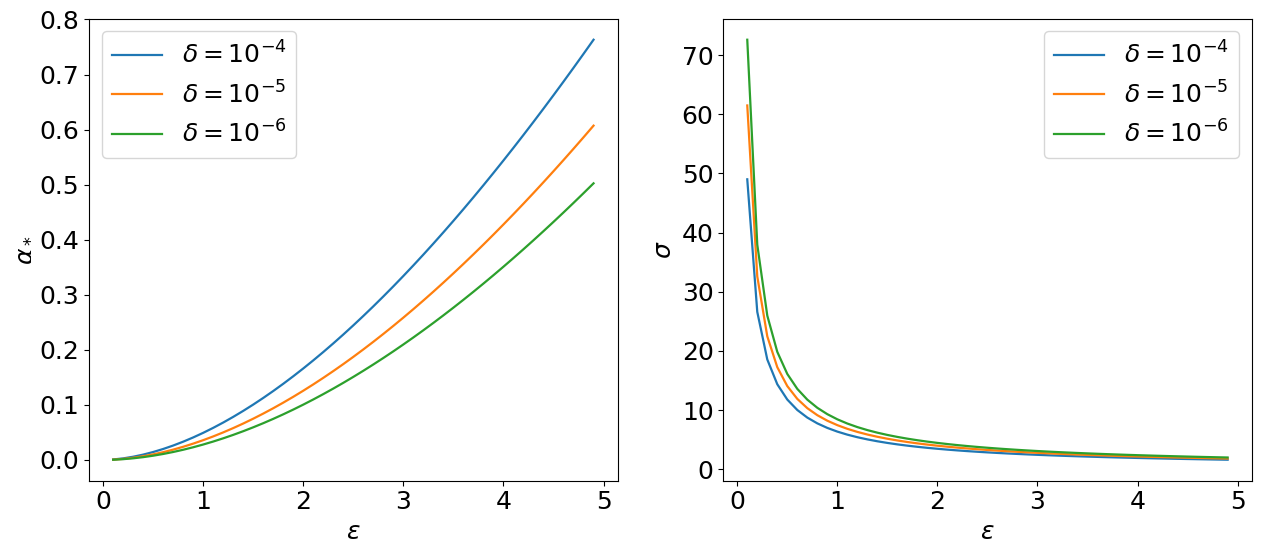

In [8]:
def delta_eps_alpha(eps, alpha):
    term1 = norm.cdf(-(eps - alpha)/math.sqrt(2*alpha))
    term2 = math.exp(eps) * norm.cdf(-(eps + alpha)/math.sqrt(2*alpha))
    return term1 - term2

def find_alpha_star(eps, delta, lo=1e-8, hi=1e8, tol=1e-10):
    while hi - lo > tol:
        mid = (lo + hi)/2
        if delta_eps_alpha(eps, mid) > delta:
            hi = mid
        else:
            lo = mid
    return (lo + hi)/2

eps_arr = np.arange(0.1, 5, 0.1)
delta_arr = [1e-4, 1e-5, 1e-6]
delta_2 = 2 #L2 sensitivity
N = 400000 #number of elements in gradient.

alpha_arr1 = []
sigma_arr1 = []
plt.figure(figsize=(15, 6))
plt.rcParams['font.size'] = 18
for delta in delta_arr:
    alpha_arr1.append([])
    sigma_arr1.append([])
    for eps in eps_arr:
        alpha_star = find_alpha_star(eps, delta)
        sigma = delta_2/(math.sqrt(2*alpha_star))
        alpha_arr1[-1].append(alpha_star)
        sigma_arr1[-1].append(sigma)
    plt.subplot(1,2,1)
    plt.plot(eps_arr, alpha_arr1[-1], linewidth=1.6, linestyle='-', label=rf'$\delta=10^{{{int(np.log10(delta))}}}$')
    plt.subplot(1,2,2)
    plt.plot(eps_arr, sigma_arr1[-1], linewidth=1.6, linestyle='-', label=rf'$\delta=10^{{{int(np.log10(delta))}}}$')


plt.subplot(1,2,1)
plt.locator_params(axis='x', nbins=10)
plt.xlabel(rf'$\epsilon$')
plt.ylabel(rf'$\alpha_*$')
plt.legend()
plt.subplot(1,2,2)
plt.locator_params(axis='x', nbins=10)
plt.xlabel(rf'$\epsilon$')
plt.ylabel(rf'$\sigma$')
plt.legend()
plt.show()
#plt.savefig('./OSGM_params_epsilon.png')

### One shot gaussian mechanism with subsampling.

<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_106986/4188055570.py:37: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(eps_arr, alpha_arr2[-1], linewidth=1.6, linestyle='-', label=rf'$\delta=10^{{{int(np.log10(delta))}}}$')


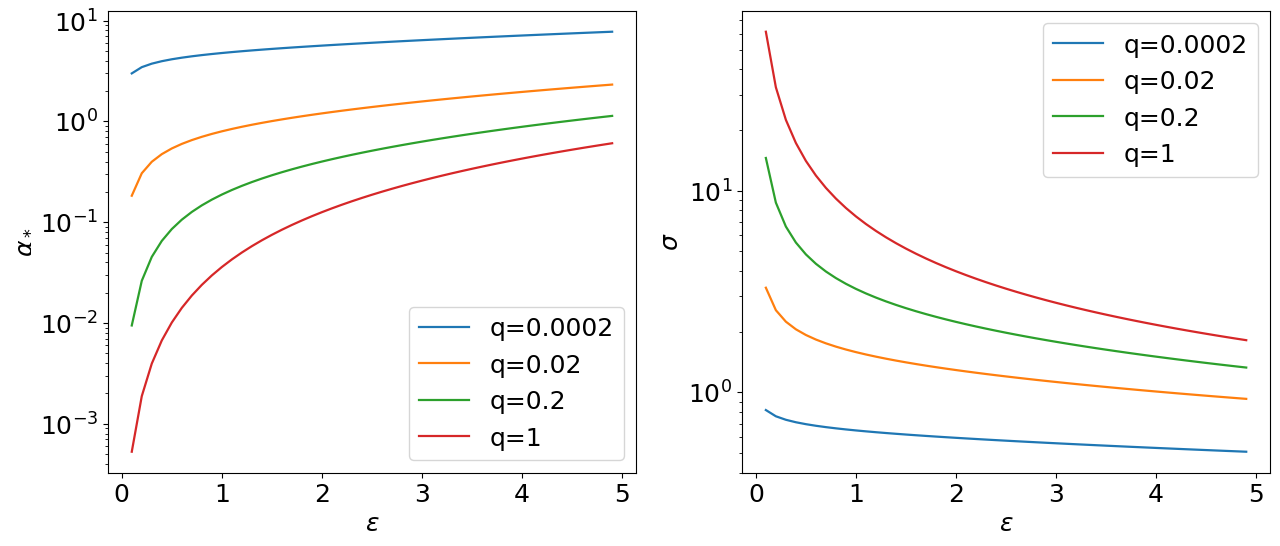

In [9]:
def delta_eps_alpha(eps, alpha, q):
    r_eps = math.log((math.exp(eps)-1+q)/q)
    term1 = (1-q-math.exp(eps)) * norm.cdf(-(r_eps + alpha)/math.sqrt(2*alpha))
    term2 = q * norm.cdf(-(r_eps - alpha)/math.sqrt(2*alpha))
    return term1 + term2

def find_alpha_star(eps, delta, q, lo=1e-8, hi=1e8, tol=1e-10):
    while hi - lo > tol:
        mid = (lo + hi)/2
        if delta_eps_alpha(eps, mid, q) > delta:
            hi = mid
        else:
            lo = mid
    return (lo + hi)/2

eps_arr = np.arange(0.1, 5, 0.1)
delta_arr = [1e-4, 1e-5, 1e-6]
delta_2 = 2 #L2 sensitivity
N = 400000 #number of elements in gradient.
B = 1
n_train = 5000
q = B/n_train

alpha_arr2 = []
sigma_arr2 = []
plt.figure(figsize=(15, 6))
'''
for delta in delta_arr:
    alpha_arr2.append([])
    sigma_arr2.append([])
    for eps in eps_arr:
        alpha_star = find_alpha_star(eps, delta, q)
        sigma = delta_2/(math.sqrt(2*alpha_star))
        alpha_arr2[-1].append(alpha_star)
        sigma_arr2[-1].append(sigma)
    plt.subplot(1,2,1)
    plt.plot(eps_arr, alpha_arr2[-1], linewidth=1.6, linestyle='-', label=rf'$\delta=10^{{{int(np.log10(delta))}}}$')
    plt.subplot(1,2,2)
    plt.plot(eps_arr, sigma_arr2[-1], linewidth=1.6, linestyle='-', label=rf'$\delta=10^{{{int(np.log10(delta))}}}$')
'''
delta = 1e-5
q_arr = [1/5000, 100/5000, 1000/5000, 1]
for q in q_arr:
    alpha_arr2.append([])
    sigma_arr2.append([])
    for eps in eps_arr:
        alpha_star = find_alpha_star(eps, delta, q)
        sigma = delta_2/(math.sqrt(2*alpha_star))
        alpha_arr2[-1].append(alpha_star)
        sigma_arr2[-1].append(sigma)
    plt.subplot(1,2,1)
    plt.semilogy(eps_arr, alpha_arr2[-1], linewidth=1.6, linestyle='-', label=rf'q={q}')
    plt.subplot(1,2,2)
    plt.semilogy(eps_arr, sigma_arr2[-1], linewidth=1.6, linestyle='-', label=rf'q={q}')

    
plt.subplot(1,2,1)
plt.locator_params(axis='x', nbins=10)
plt.xlabel(rf'$\epsilon$')
plt.ylabel(rf'$\alpha_*$')
plt.legend()
plt.subplot(1,2,2)
plt.locator_params(axis='x', nbins=10)
plt.xlabel(rf'$\epsilon$')
plt.ylabel(rf'$\sigma$')
plt.legend()
plt.show()
#plt.savefig('./subOSGM_params_epsilon_q.png')

# Experiment with DP-SGD and moments accountant

In [7]:
B=1
X, y, means = prepare_mnist(5000)
train_loader , test_loader, total_samples = prepare_data_loader(X, y, batch_size=B)

epochs = 3
epsilon = 0.99
delta=1e-5
max_grad_norm = 1
noise_multiplier = 0.5

model = MLP(X.shape[1], 10, hidden_dim=512)
loss_function = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# enter PrivacyEngine
privacy_engine = PrivacyEngine()
model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=noise_multiplier,
    max_grad_norm=max_grad_norm,
)

train(epochs, optimizer, loss_function)

print(privacy_engine.accountant.history)
eps = privacy_engine.get_epsilon(delta=delta)
print(f'eps: {eps}')

/home/tom/Documents/University/thesis/code/my_dlg/venv/lib/python3.13/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_59207/813122683.py:14: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Epoch 1: Test acc: 0.2720, train acc: 0.1926, epoch loss: nan
Epoch 2: Test acc: 0.3190, train acc: 0.3104, epoch loss: nan
Epoch 3: Test acc: 0.3260, train acc: 0.3185, epoch loss: nan
[(0.5, 0.00025, 12000)]
eps: 2.391363635015632


In [10]:
from opacus.accountants.utils import get_noise_multiplier  
noise_multiplier = get_noise_multiplier(
    target_epsilon=1.0,
    target_delta=1e-5,
    sample_rate=B/5000,
    epochs=15,
    accountant="rdp",
    alphas= [1 + x / 10.0 for x in range(1, 100)] + list(range(12, 64))
)
print(noise_multiplier)

0.791015625


/home/tom/Documents/University/thesis/code/my_dlg/venv/lib/python3.13/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


In [11]:
def train_dp(epochs, optimizer, loss_function, delta=1e-5, track_every=1):
    """
    DP training loop that tracks epsilon at every iteration.

    Args:
        epochs (int): number of epochs
        optimizer: DP-wrapped optimizer from Opacus
        loss_function: e.g., nn.CrossEntropyLoss()
        delta (float): target delta for DP
        track_every (int): track epsilon every N iterations
    Returns:
        history_eps (list): list of tuples (iteration, epsilon)
        loss_history (list): list of per-iteration loss
    """
    loss_history = []
    history_eps = []

    global_step = 0

    for epoch in range(epochs):
        model.train()
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_function(outputs, y_batch)
            loss.backward()
            optimizer.step()

            # record loss
            loss_history.append(loss.item())
            global_step += 1

            # track epsilon every 'track_every' steps
            if global_step % track_every == 0:
                epsilon = privacy_engine.get_epsilon(delta=delta)
                history_eps.append((global_step, epsilon))
                print(f'Epoch: {epoch}, step: {global_step}, eps: {epsilon}')

    return history_eps, loss_history

In [14]:
B=1
X, y, means = prepare_mnist(5000)
train_loader , test_loader, total_samples = prepare_data_loader(X, y, batch_size=B)

epochs = 3
epsilon = 0.99
delta=1e-5
max_grad_norm = 1
noise_multiplier = 0.1

model = MLP(X.shape[1], 10, hidden_dim=512)
loss_function = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# enter PrivacyEngine
privacy_engine = PrivacyEngine()
model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=noise_multiplier,
    max_grad_norm=max_grad_norm,
    alphas= [1 + x / 10.0 for x in range(1, 100)] + list(range(12, 64))
)

history_eps, loss_history = train_dp(epochs, optimizer, loss_function, delta=delta, track_every=100)


/tmp/ipykernel_22332/1155538470.py:26: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Epoch: 0, step: 100, eps: 109.81408534197348
Epoch: 0, step: 200, eps: 126.5359109535713
Epoch: 0, step: 300, eps: 142.97462480556516
Epoch: 0, step: 400, eps: 152.93113094778136
Epoch: 0, step: 500, eps: 161.2432282728839


KeyboardInterrupt: 

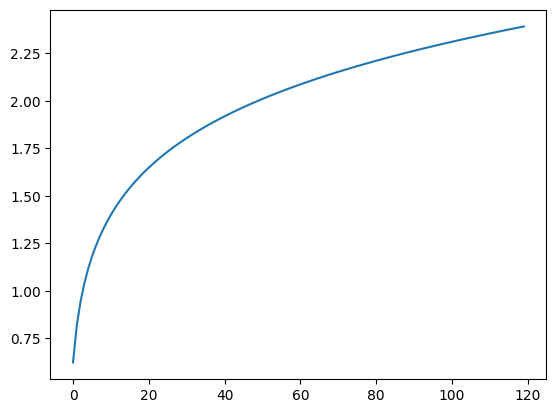

In [51]:
eps = [tup[1] for tup in history_eps]
plt.plot(eps)